# Session 2 – When Models Become Too Simple or Too Complex

In machine learning you often hear terms like:

- **overfitting**
- **underfitting**
- **model complexity**

But what do these actually mean?

Where do they come from?  
Why do they happen?  
And how can we recognize them when training models?

In the previous session we used **simple visual datasets** to understand how models behave.  
We will continue with the same idea here.

Instead of formulas, we will use **visual experiments** to see how models change when we adjust their settings.

Many machine learning models have settings that control **how flexible the model is**.  
For example:

- polynomial degree in polynomial regression
- tree depth in decision trees
- number of neighbors in kNN
- regularization strength in regression
- parameters in SVM models

These settings control **how complex the model can become**.

In this notebook we explore a simple question:

**What happens when a model is too simple or too complex for the data?**

We will use visual experiments to observe three phenomena:

- **Underfitting** (model too simple)  
- **Good generalization**  
- **Overfitting** (model too complex)

Our goal is to build intuition for the **bias–variance tradeoff**.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Step 1 – Create a Simple Learning Problem

In real machine learning problems we never see the **true function**.

We only see **noisy observations**.

To simulate this situation we create:

- a **true function** (a sine wave)
- **observations** that contain noise

The model will only see the noisy observations.

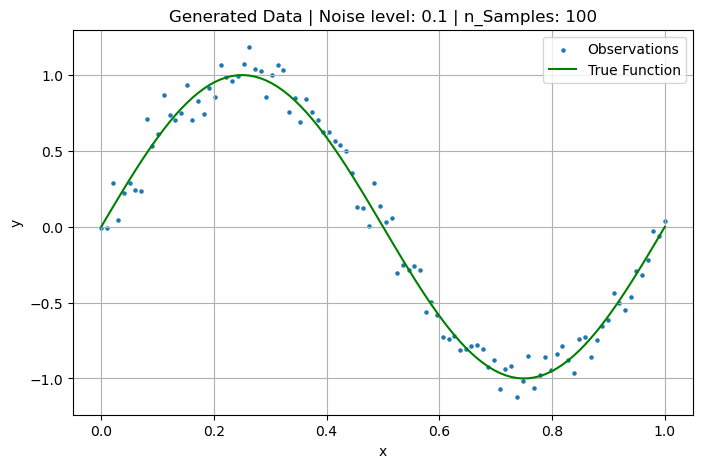

In [3]:
def generate_sine_data(
    A=1,
    omega=2*np.pi,
    noise_level=0.1,
    n_samples=100,
    x_range=(0, 1),
    plot=False
):
    """
    Generate a noisy sine dataset.
    
    Returns:
    - x: input features, shape (n_samples,1)
    - y: noisy observations, shape (n_samples,1)
    - y_true: true sine values, shape (n_samples,1)
    - sine_func: function handle for the true function
    """
    x = np.linspace(x_range[0], x_range[1], n_samples).reshape(-1,1)
    sine_func = lambda x_: A * np.sin(omega * x_)
    y_true = sine_func(x)
    noise = noise_level * np.random.randn(n_samples, 1)
    y = y_true + noise
    
    if plot:
        plt.figure(figsize=(8,5))
        plt.scatter(x, y, s=5, label="Observations")
        plt.plot(x, y_true, c='green', label="True Function")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title(f"Generated Data | Noise level: {noise_level} | n_Samples: {n_samples}")
        plt.legend()
        plt.grid()
        plt.show()
    
    return x, y, y_true, sine_func

# Generate training data
noise_level=0.1
n_samples=100
x_train, y_train, y_true, sine_func = generate_sine_data(noise_level=noise_level, n_samples=n_samples, plot=True)


# Step 2 – Build a Model (Explained Simply)

We use **linear regression** to learn weights for our features.

But wait — our data is curved (like a sine wave), not straight. How can a linear model fit a curve?

Trick: we do **feature engineering**:

* We take the original input x and create new features: x², x³, x⁴, … up to degree d.
* Now the input features are `[1, x, x², x³, ... x^d]`.

This is **still linear regression**:

* We are learning weights `[w0, w1, w2, ..., wd]`
* Prediction: `y = w0 + w1*x + w2*x² + ... + wd*x^d`

Notice:

* Linear in weights → training is still easy (linear regression math works)
* Nonlinear in x → we can now fit curves, not just straight lines

Example: Degree 3

* Features: [1, x, x², x³]
* Weights: [0.5, 2.0, -1.0, 0.3]
* Prediction: y = 0.5 + 2*x - 1*x² + 0.3*x³

We are learning a curve by **linearly combining polynomial features**. You can see these features at the end of the notebook.

### Model Complexity

Try changing the value of **DEGREE**.

Examples to try:

DEGREE = 1

DEGREE = 3

DEGREE = 7

DEGREE = 15


Questions to think about:

- When does the model become **too simple**?
- When does the model become **too flexible**?

In [4]:
DEGREE= 15 # controls how complex the model is, integer between 1-... (> 5 is large!)
model = make_pipeline(PolynomialFeatures(DEGREE), LinearRegression())
print(model)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=15)),
                ('linearregression', LinearRegression())])


In [5]:
x_train= x_train.reshape(-1,1)
y_train= y_train.reshape(-1,1)
print(f"{x_train.shape},   {y_train.shape}")
model.fit(x_train, y_train) # train (tune  model parameters)

(100, 1),   (100, 1)


,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,15
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [6]:
# %%
from sklearn.metrics import mean_squared_error

degrees = [1, 3, 5, 7, 10, 15]
train_errors, test_errors = [], []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(x_train, y_train)
    
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    
    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))
    
    # Plot fit
    plt.figure(figsize=(8,5))
    plt.scatter(x_train, y_train, s=5, label="Train Data")
    plt.plot(x_test, y_test, c='green', label="True Function")
    plt.plot(x_test, y_test_pred, c='red', label=f"Predicted (degree {d})")
    plt.title(f"Polynomial Degree {d}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid()
    plt.show()

NameError: name 'x_test' is not defined

# Step 4 – Extrapolation and Testing the Model on OOD data (Out of Distribution)

The model was trained on data x between:

0 and 1
|
Now we test it slightly **outside the training region**.

This helps us check whether the model learned the **true pattern** or simply memorized the training points.

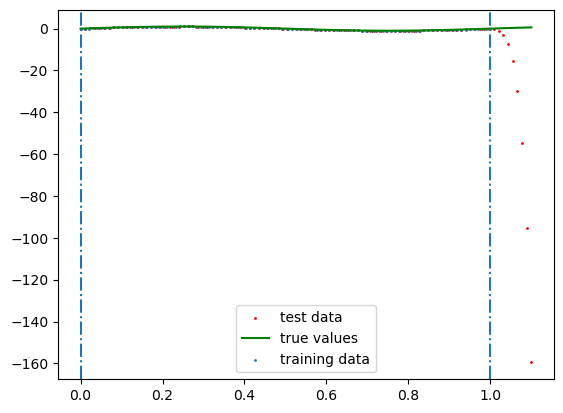

In [ ]:
Test_span= 1.1

x_test= np.linspace(0,Test_span,97).reshape(-1,1)
y_pred= model.predict(x_test)
y_test=  sine_func(x_test)

plt.scatter(x_test,y_pred,s=1,c='red', label= 'test data')
plt.plot(x_test,y_test, c= 'green', label= 'true values')
plt.scatter(x_train,model.predict(x_train),s=1, label='training data')
plt.axvline(0, linestyle='-.')
plt.axvline(1, linestyle='-.')
plt.legend()


Typical data lies on a manifold in the input space, basically, the “region” of space where normal examples live.

OOD examples are also off the manifold, but usually in a much larger sense, they come from a completely different distribution.

Adversarial examples are intentionally designed to push the input off that manifold, into regions where the model hasn’t learned reliable behavior.

**Questions** Find some adversarial examples in AI for vision applications. 

In [ ]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# %%
# --- Data Generation Function ---
def generate_sine_data(
    A=1,
    omega=2*np.pi,
    noise_level=0.1,
    n_samples=100,
    x_range=(-0.5, 0.5),  # now centered around 0
    plot=False
):
    """
    Generate a noisy sine dataset.
    
    Returns:
    - x: input features, shape (n_samples,1)
    - y: noisy observations, shape (n_samples,1)
    - y_true: true sine values, shape (n_samples,1)
    - sine_func: function handle for the true function
    """
    x = np.linspace(x_range[0], x_range[1], n_samples).reshape(-1,1)
    sine_func = lambda x_: A * np.sin(omega * x_)
    y_true = sine_func(x)
    noise = noise_level * np.random.randn(n_samples, 1)
    y = y_true + noise
    
    if plot:
        plt.figure(figsize=(8,5))
        plt.scatter(x, y, s=5, label="Observations")
        plt.plot(x, y_true, c='green', label="True Function")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title(f"Generated Data | Noise level: {noise_level} | n_Samples: {n_samples}")
        plt.legend()
        plt.grid()
        plt.show()
    
    return x, y, y_true, sine_func

# Generate training data
x_train, y_train, y_true_train, sine_func = generate_sine_data(noise_level=0.1, n_samples=100, plot=True)

# Generate test data slightly outside the training range
x_test = np.linspace(-0.6, 0.6, 200).reshape(-1,1)
y_test = sine_func(x_test)

# %%
# --- Sweep Polynomial Degrees and Compare Regularizations ---
degrees = [1, 3, 5, 7, 10, 15]
reg_methods = {
    "None": LinearRegression(),
    "L2 (Ridge, alpha=0.1)": Ridge(alpha=0.1),
    "L1 (Lasso, alpha=0.01)": Lasso(alpha=0.01, max_iter=10000)  # small alpha for demo
}

for reg_name, reg_model in reg_methods.items():
    print(f"--- Regularization: {reg_name} ---")
    
    for d in degrees:
        # Create polynomial features + linear/regression model
        model = make_pipeline(PolynomialFeatures(d), reg_model)
        model.fit(x_train, y_train)
        
        # Predictions
        y_train_pred = model.predict(x_train)
        y_test_pred = model.predict(x_test)
        
        # Compute errors
        train_mse = mean_squared_error(y_train, y_train_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        
        print(f"Degree {d} | Train MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f}")
        
        # Plot fit
        plt.figure(figsize=(8,5))
        plt.scatter(x_train, y_train, s=5, label="Train Data")
        plt.plot(x_test, y_test, c='green', label="True Function")
        plt.plot(x_test, y_test_pred, c='red', label=f"Predicted (degree {d})")
        plt.title(f"{reg_name} | Degree {d}")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.legend()
        plt.grid()
        plt.show()
        
        # --- Plot Weights ---
        # Extract weights from the regression step
        weights = model.named_steps[list(model.named_steps.keys())[-1]].coef_
        # LinearRegression has shape (1, n_features) but Ridge/Lasso can be 1D
        weights = weights.ravel() if len(weights.shape) > 1 else weights
        plt.figure(figsize=(8,4))
        plt.bar(range(len(weights)), weights)
        plt.xlabel("Polynomial Feature Index")
        plt.ylabel("Weight Value")
        plt.title(f"{reg_name} | Degree {d} | Weights Magnitude")
        plt.grid()
        plt.show()

# Extra

# What Does "Polynomial Degree" Mean?

Polynomial regression creates new features:

x, x², x³, x⁴ ...

These allow the model to create **curved shapes**.

The plot below shows how polynomial basis functions look.

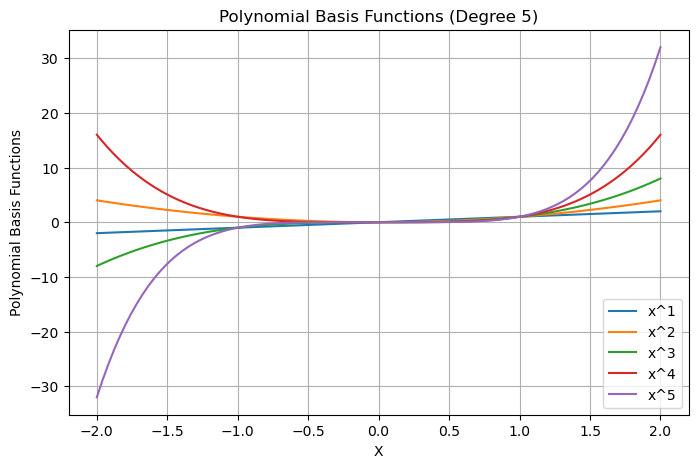

In [ ]:
# Generate input values (X-axis)
X = np.linspace(-2, 2, 100).reshape(-1, 1)

def plot_polynomial_basis(degree):
    """Generate and plot polynomial basis functions up to a given degree."""
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(X)  # Create polynomial features

    plt.figure(figsize=(8, 5))

    for i in range(1, degree + 1):  # Ignore the bias term (column 0)
        plt.plot(X, X_poly[:, i], label=f"x^{i}")

    plt.xlabel("X")
    plt.ylabel("Polynomial Basis Functions")
    plt.title(f"Polynomial Basis Functions (Degree {degree})")
    plt.legend()
    plt.grid()
    plt.show()


plot_polynomial_basis(5)


# Model Complexity Control via Regularization

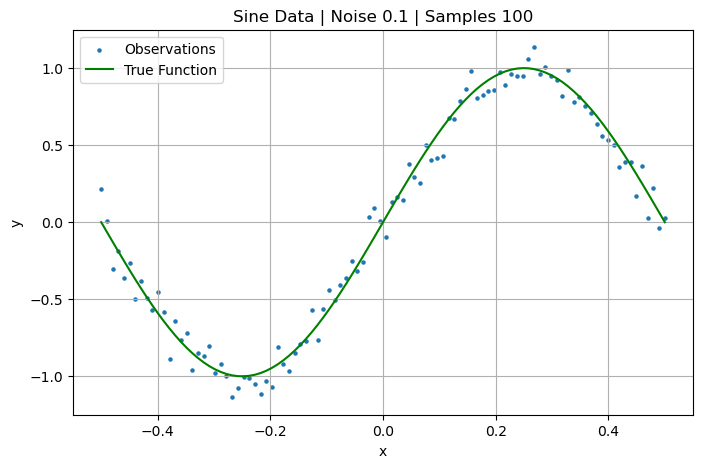

In [ ]:


def generate_sine_data(
    A=1,
    omega=2*np.pi,
    noise_level=0.1,
    n_samples=100,
    x_range=(-0.5, 0.5),
    plot=False
):
    x = np.linspace(x_range[0], x_range[1], n_samples).reshape(-1,1)
    sine_func = lambda x_: A * np.sin(omega * x_)
    y_true = sine_func(x)
    noise = noise_level * np.random.randn(n_samples,1)
    y = y_true + noise
    if plot:
        plt.figure(figsize=(8,5))
        plt.scatter(x, y, s=5, label="Observations")
        plt.plot(x, y_true, c='green', label="True Function")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title(f"Sine Data | Noise {noise_level} | Samples {n_samples}")
        plt.legend()
        plt.grid()
        plt.show()
    return x, y, y_true, sine_func

x_train, y_train, y_true_train, sine_func = generate_sine_data(plot=True)
x_test = np.linspace(-0.6,0.6,200).reshape(-1,1)
y_test = sine_func(x_test)

# Step 1 – So Far, We Controlled Complexity via Degree

Up until now we increased **model flexibility** by increasing the **polynomial degree**.

But what happens to the **weights** as the degree increases?  
- Are they reasonable?
- Do they stay small or explode?  

Let's explore the weights for different polynomial degrees while keeping **linear regression**.

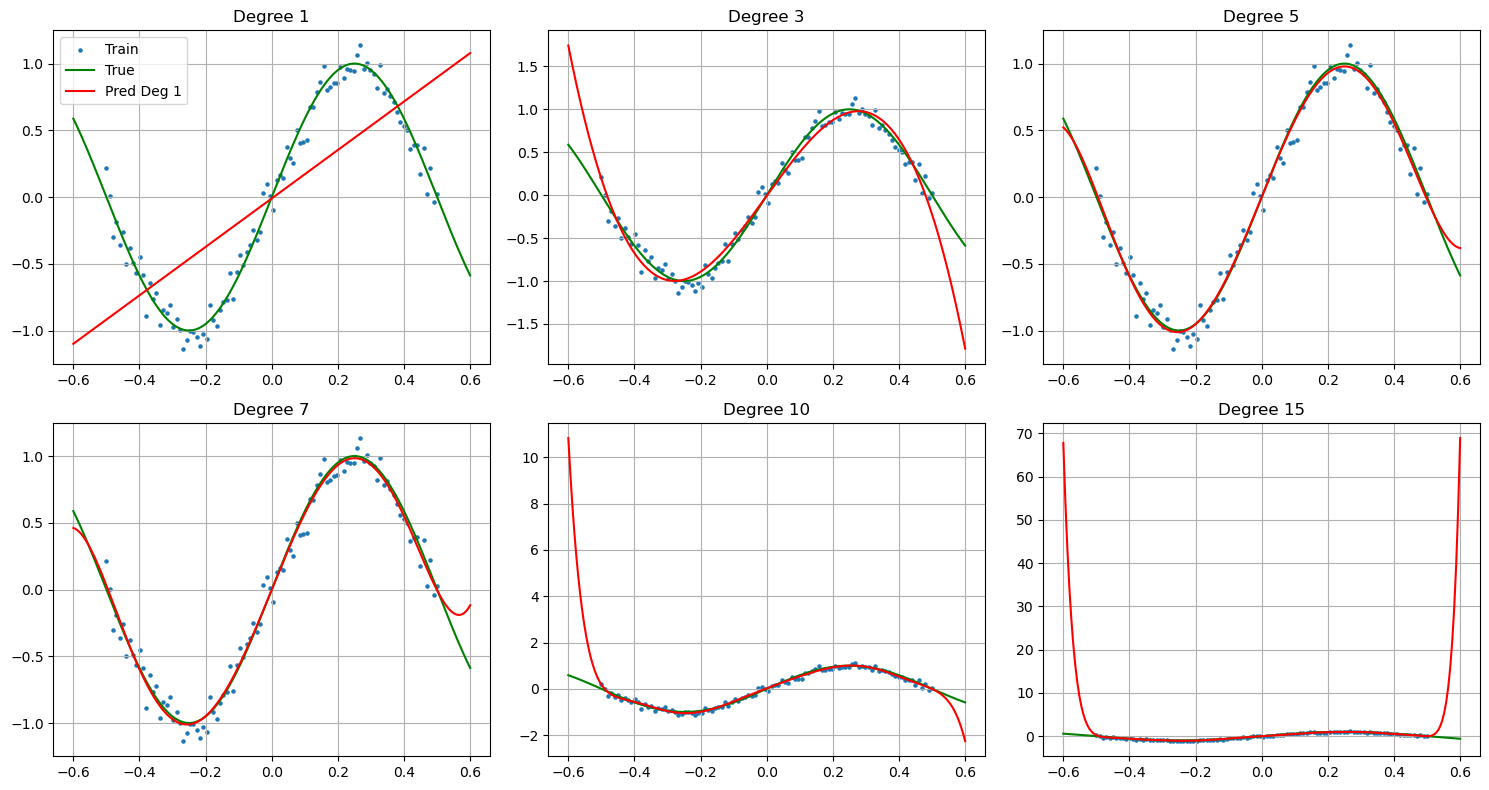

,x^0,x^1,x^2,x^3,x^4,x^5,x^6,x^7,x^8,x^9,x^10,x^11,x^12,x^13,x^14,x^15
Degree 1,0.0,1.815398,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Degree 3,0.0,5.332332,-0.041503,-22.985009,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Degree 5,0.0,6.117491,-0.397454,-37.361628,1.628756,50.761418,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Degree 7,0.0,6.077415,-0.144642,-35.945213,-1.348090,38.525827,8.567168,29.737353,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Degree 10,0.0,5.495874,-3.075279,-2.411898,52.907439,-475.573611,-237.213464,2916.402550,-263.844926,-5357.118936,2318.153834,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Degree 15,0.0,5.029831,0.922543,57.610113,-242.096792,-2722.519170,7663.045325,40086.396488,-98822.399727,-321039.035380,623664.755778,1.433322e+06,-1.919754e+06,-3.302358e+06,2.309119e+06,3.026571e+06


In [ ]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import numpy as np

degrees = [1, 3, 5, 7, 10, 15]
weights_dict = {}
predictions_dict = {}

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(x_train, y_train)
    
    # Save weights
    weights = model.named_steps['linearregression'].coef_.ravel()
    weights_dict[d] = weights
    
    # Save predictions
    predictions_dict[d] = model.predict(x_test)

# --- Plot predictions in a grid
ncols = 3
nrows = int(np.ceil(len(degrees)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 8))
axes = axes.ravel()

for i, d in enumerate(degrees):
    ax = axes[i]
    ax.scatter(x_train, y_train, s=5, label="Train")
    ax.plot(x_test, y_test, c='green', label="True")
    ax.plot(x_test, predictions_dict[d], c='red', label=f"Pred Deg {d}")
    ax.set_title(f"Degree {d}")
    ax.grid(True)
    if i==0: ax.legend()
    
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

# --- Create a cleaner DataFrame for weights
weights_table = pd.DataFrame.from_dict(
    {f"Degree {d}": np.pad(w, (0, max(len(w) for w in weights_dict.values()) - len(w)), constant_values=0) 
     for d, w in weights_dict.items()},
    orient='index',
    columns=[f"x^{i}" for i in range(max(len(w) for w in weights_dict.values()))]
)

weights_table

In [ ]:
import seaborn as sns

# --- Heatmap of weights
plt.figure(figsize=(12, 6))
sns.heatmap(weights_table, annot=False, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Weight Value'})
plt.xlabel("Polynomial Feature")
plt.ylabel("Polynomial Degree")
plt.title("Heatmap of Linear Regression Weights for Different Degrees")
plt.show()

You see that the weights for larger models are HUGE. In the order of millions.

# Step 2 – Observation: Weights Explode

Notice that for higher degrees:  
- The weights get **very large**  
- The model is extremely sensitive to noise  

Can we **control complexity** without reducing the degree?  

Yes! We can **penalize large weights**, which is what **L2 regularization (Ridge)** does:
- Adds a cost proportional to the **square of the weights**  
- Keeps weights small, stabilizing the model|

# Ridge Regression to the rescue!

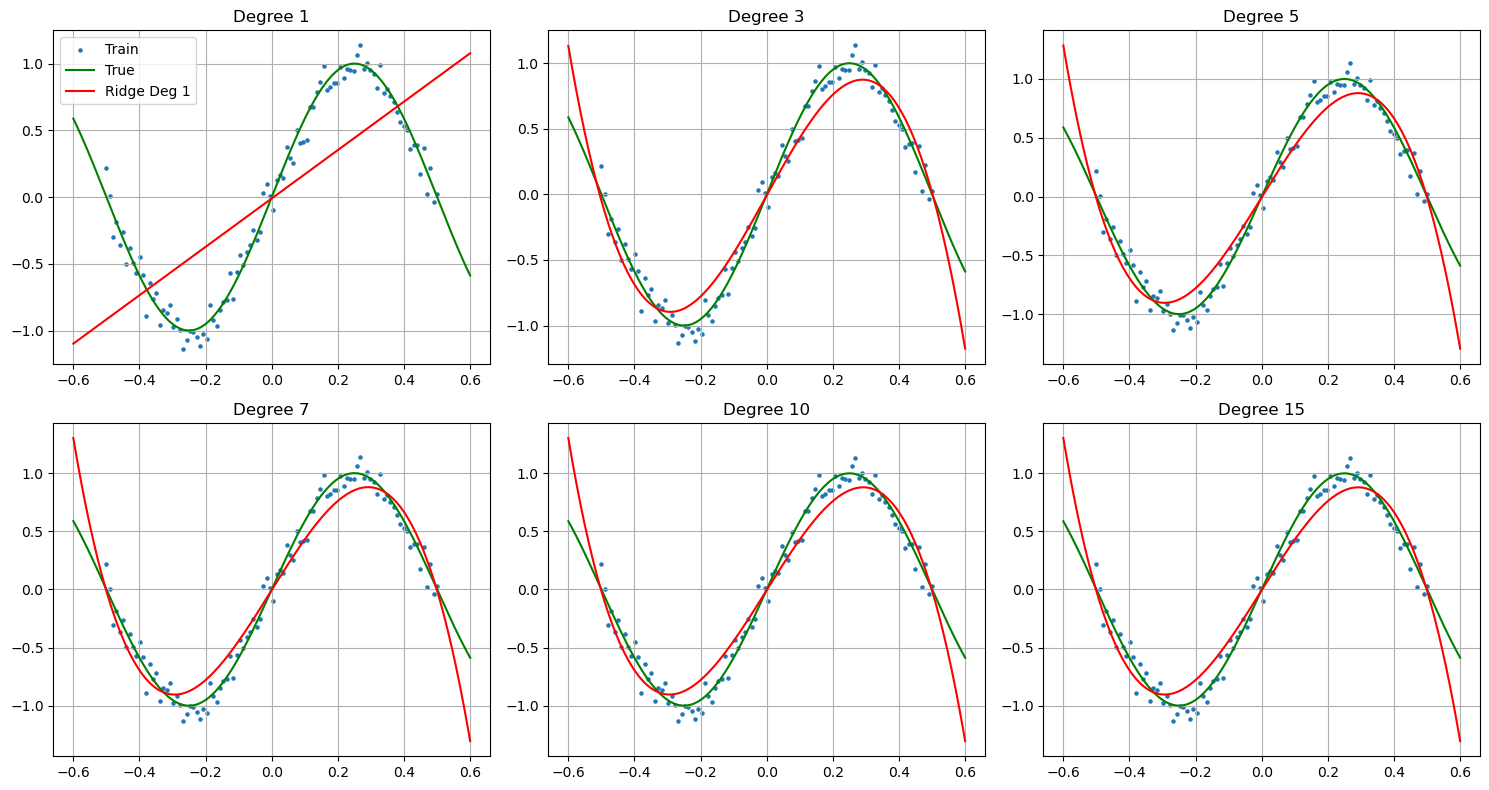

Here are the weights of different terms for different degrees.


,x^0,x^1,x^2,x^3,x^4,x^5,x^6,x^7,x^8,x^9,x^10,x^11,x^12,x^13,x^14,x^15
Degree 1,0.0,1.813265,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Degree 3,0.0,4.570097,-0.040797,-18.038532,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Degree 5,0.0,4.544208,-0.105669,-17.129903,0.301976,-4.058822,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Degree 7,0.0,4.541964,-0.109061,-17.087961,0.293602,-4.041730,0.113751,-0.840992,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Degree 10,0.0,4.541831,-0.109278,-17.085951,0.292819,-4.040830,0.113466,-0.840711,0.037761,-0.174066,0.011635,0.000000,0.000000,0.000000,0.000000,0.000000
Degree 15,0.0,4.541823,-0.109279,-17.085847,0.292815,-4.040780,0.113464,-0.840695,0.037760,-0.174062,0.011635,-0.036721,0.003393,-0.007926,0.000952,-0.001748


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
import numpy as np

ridge_alpha = 0.01 # this controls the complexity of the ridge_alpha
weights_ridge_dict = {}
predictions_ridge_dict = {}

# --- Train Ridge models for different degrees
for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), Ridge(alpha=ridge_alpha))
    model.fit(x_train, y_train)
    
    # Save weights
    weights_ridge_dict[d] = model.named_steps['ridge'].coef_.ravel()
    
    # Save predictions
    predictions_ridge_dict[d] = model.predict(x_test)

# --- Create Ridge weights DataFrame (cleaner method)
weights_ridge_table = pd.DataFrame.from_dict(
    {f"Degree {d}": w for d, w in weights_ridge_dict.items()},
    orient='index'
).fillna(0)


# --- Grid of predictions
ncols = 3
nrows = int(np.ceil(len(degrees)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 8))
axes = axes.ravel()

for i, d in enumerate(degrees):
    ax = axes[i]
    ax.scatter(x_train, y_train, s=5, label="Train")
    ax.plot(x_test, y_test, c='green', label="True")
    ax.plot(x_test, predictions_ridge_dict[d], c='red', label=f"Ridge Deg {d}")
    ax.set_title(f"Degree {d}")
    ax.grid(True)
    if i==0: ax.legend()

# Hide any extra axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

# Rename columns to x^i
weights_ridge_table.columns = [f"x^{i}" for i in range(weights_ridge_table.shape[1])]
print("Here are the weights of different terms for different degrees.")
weights_ridge_table

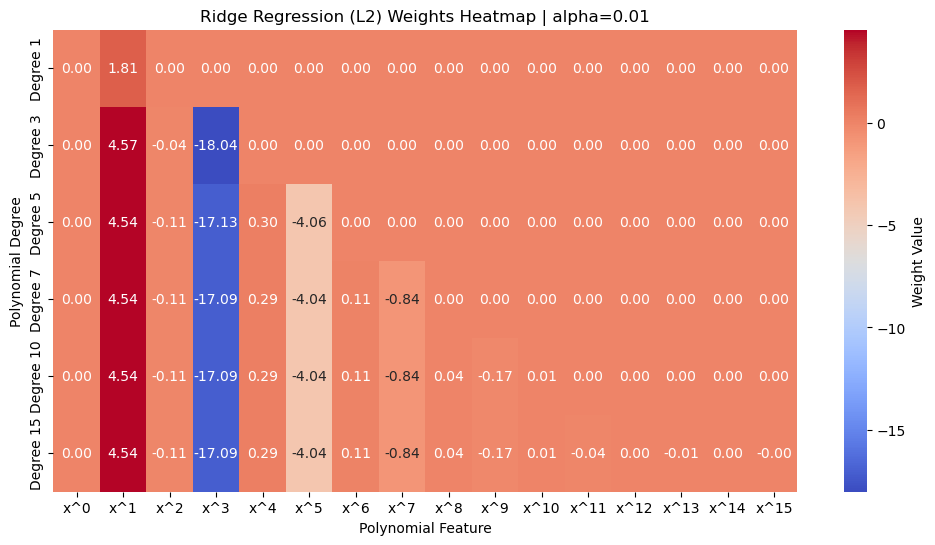

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(weights_ridge_table, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Weight Value'})
plt.xlabel("Polynomial Feature")
plt.ylabel("Polynomial Degree")
plt.title(f"Ridge Regression (L2) Weights Heatmap | alpha={ridge_alpha}")
plt.show()

## Observations from Ridge Regression
Look at the tables and plots from the Ridge regression above. You can see two key things:
1. Controlled weight magnitudes
- Even for very high-degree polynomials, the weights no longer explode.
- The Ridge regularization prevents the model from assigning huge values to any polynomial term.
2. Selective feature importance
- Higher-degree features are still used, so the model can fit curves.
- However, even-power features (like x², x⁴, …) have much smaller weights.
- Why is that? Think about the sine curve’s symmetry around zero:
- Sine is an odd function, symmetric around the origin.
- Even functions (x², x⁴, …) are symmetric in the opposite way, so they do not contribute as much to fitting the sine shape.
- Ridge sees this and naturally shrinks their weights.
You can see that L2 regularization controls the model complexity by shrinking weights, rather than removing them entirely.
Next question: What if we want to force some weights exactly to zero?
This is where L1 regularization (Lasso) comes in.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline
import numpy as np

lasso_alpha = 0.01  # controls the strength of L1 regularization
weights_lasso_dict = {}
predictions_lasso_dict = {}

# --- Train Lasso models for different degrees
for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), Lasso(alpha=lasso_alpha, max_iter=10000))
    model.fit(x_train, y_train)
    
    # Save weights
    weights_lasso_dict[d] = model.named_steps['lasso'].coef_.ravel()
    
    # Save predictions
    predictions_lasso_dict[d] = model.predict(x_test)

# --- Create Lasso weights DataFrame (clean method)
weights_lasso_table = pd.DataFrame.from_dict(
    {f"Degree {d}": w for d, w in weights_lasso_dict.items()},
    orient='index'
).fillna(0)

# Rename columns to x^i
weights_lasso_table.columns = [f"x^{i}" for i in range(weights_lasso_table.shape[1])]

print("Here are the Lasso (L1) weights for different degrees:")
weights_lasso_table

# --- Grid of predictions
ncols = 3
nrows = int(np.ceil(len(degrees)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 8))
axes = axes.ravel()

for i, d in enumerate(degrees):
    ax = axes[i]
    ax.scatter(x_train, y_train, s=5, label="Train")
    ax.plot(x_test, y_test, c='green', label="True")
    ax.plot(x_test, predictions_lasso_dict[d], c='blue', label=f"Lasso Deg {d}")
    ax.set_title(f"Degree {d}")
    ax.grid(True)
    if i==0: ax.legend()

# Hide any extra axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

NameError: name 'degrees' is not defined

# L1 and L2 Regularization For Linear Regression